# Packages

In [27]:
import klayout.db as kdb
import matplotlib.pyplot as plt
import skimage.graph as skg
import numpy as np

from pathlib import Path
from importlib import reload
from matplotlib.colors import TwoSlopeNorm
from matplotlib.animation import FuncAnimation

import Map
reload(Map)
import PinMatcher
reload(PinMatcher)
import Krouter
reload(Krouter)

from Map import Map
from PinMatcher import PinMatcher
from Krouter import Krouter


# Routing

## Initialize Krouter

首先输入 gds 文件的相关参数，初始化 Krouter 对象
- file_path: gds 文件路径
- cell: 顶层 cell 名称
- bbox_layer: 用于定义布局边界的 layer
- pin_layer: 用于定义引脚的 layer
- obs_rules (list[dict]): List of obstacle rules, each rule is a dictionary with keys:
    - "layers": Layer(s) containing obstacles, can be a string or a list of strings.
    - "bbx": Whether to use bounding box for the shapes. 是否对图案使用边界框
    - "pad": Padding size for the shapes in microns. 将图案扩展多少微米
- map_resolution: 对 layout 进行网格化时的像素尺寸，单位为微米

obs_rules代表将哪些图层的图案作为障碍物，且在将它们变成障碍物之前，可以选择是否对图案使用边界框以及扩展多少微米。padded bouding box of the shapes将会作为障碍物插入 `Map` 中，路径将永远不会经过障碍物区域。

In [51]:
file_path = Path("../demo.gds")
cell = "Top"

bbox_layer = "7/0"
pin_a_layer = "102/1"
pin_b_layer = "111/1"

obs_rules = [
    {
        "layers": ["1/0", "2/0"],
        "bbx": True,
        "pad": 6
    },
]

map_resolution = 5


根据这些参数初始化 `Krouter` 对象后，会自动加载 gds 文件并创建布局的网格化表示 `Map`。

这一步将备份 .gds 原文件到 `xxx_backup.gds`，注意检查。

In [52]:
Krt = Krouter(
			file_path=file_path,
			cell_name=cell,						
			total_area_bbox_layer=bbox_layer,
			Pin_A_layer=pin_a_layer,
			Pin_B_layer=pin_b_layer,
			map_resolution=map_resolution,
			obs_rules=obs_rules,
			)


Map: Created a 768x751 map matrix with a resolution of 5.0 µm.
Krouter: Collecting region from layer 1/0.
Krouter: Collecting region from layer 2/0.
PinMatcher: Added 42 pins to Pin set A.
PinMatcher: Added 42 shapes to shape set A.
PinMatcher: Added 42 pins to Pin set B.
PinMatcher: Added 42 shapes to shape set B.


## Match pins

在做寻路之前，必须先匹配引脚。详见 `Auto-routing/manual.md`.

`hungarian_match()` 将会做全局最优匹配，找到使全局直线距离最短的匹配方案。而 `Krt.save_layout()` 会把这个匹配方案保存在 layout 的一个新的图层中，方便查看错误和进行修改。

hungarian match 可以为我们提供一个还不错的匹配方案，但在某些情况下，这种全局直线距离最短的匹配方案在拓扑上是有错误的，使得某些配对的引脚之间并不存在合理路径。因此，在做完这一步匹配后必须在 Klayout 中手动检查匹配是否合理，并修改拓扑错误（推荐使用Klayout GUI中的 *partial* 方法修改连线的端点，这一步通常十分简单）

修正匹配后保存文件，后面的寻路过程会从该匹配图层读取匹配结果，并按照修改后的匹配结果进行布线。

*我知道这个方法十分的不优雅，需要人工介入。但是我目前没有想到能够自动解决拓扑错误的匹配方案，这里有待改进*

In [46]:
Krt.PinMatcher.hungarian_match()
Krt.PinMatcher.visualize(Krt.layout, Krt.cell)
Krt.save_layout()  # 完成后去 Klayout GUI 中检查并修正匹配结果

PinMatcher: Found 42 matched pins using Hungarian algorithm.
PinMatcher: Visualized 42 matched pins on layer "Match".
Krouter: Layout saved to ..\demo.gds.


## Run routing

### routing parameters

现在可以开始布线了。首先需要输入一系列参数，所有长度单位均为 $\mu \text{m}$.
- 首先是 soft safe distance。这里输入的 distance 表示路径会尽可能保持的距离，但并不绝对。
    - obs_safe_distance: path 与 obstacle 边界之间的安全距离; 这里的 obstacle 是指 `obs_rules` 中定义的、经过 padding 和 bounding box 处理后的障碍物
    - Pin_A_safe_distance: path 与 pin A 边界之间的安全距离
    - Pin_B_safe_distance: path 与 pin B 边界之间的安全距离
- 因为是 soft constraint，所以需要定义 hardness 来表示违反该约束时的惩罚力度，数值越大表示越不允许违反该约束
    - obs_hardness: hardness for obstacles
    - pin_hardness: hardness for pins, 这里 A 和 B 使用相同的 hardness
- `Path` 相关参数
    - path_safe_dist: 路径与路径彼此之间的安全距离
    - path_hardness: hardness for paths
    - routing_path_width: 寻路时路径的宽度
- match_layer: 上一步用于存储匹配结果的图层
- routing_path_layer: 寻路结果将会被插入到 layout 的该图层中

In [49]:
# Routing parameters
obs_safe_distance = 16
obs_hardness = 20

Pin_A_safe_distance = 20
Pin_B_safe_distance = 200
pin_hardness = 20

path_safe_distance = 20
path_hardness = 10
routing_path_width = 4

match_layer = "202/0"
routing_path_layer = "114/0"

准备工作完成，后面都是自动化了

In [50]:
path_density_hardness = 1
round = 1

def compute_damping_steps(safe_dist, max_steps=10, magnification=1.5):
    """根据 map resolution 和 safe distance 自动计算阻尼步数"""
    return min(max_steps, int(safe_dist / map_resolution * magnification))

obs_damping_step = compute_damping_steps(obs_safe_distance)
Pin_A_damping_step = compute_damping_steps(Pin_A_safe_distance)
Pin_B_damping_step = compute_damping_steps(Pin_B_safe_distance)
path_damping_step = compute_damping_steps(path_safe_distance)

### route without animation

In [ ]:
# Read matched pins from match layer
Krt.PinMatcher.read_match(kdb.Region(Krt.cell.shapes(Krt.try_find_layer(match_layer))))

# You can choose to sort the matched pins by shortest distance or by clockwise 
Krt.PinMatcher.sort_matched_pins()
# Krt.PinMatcher.clockwise_sort(counter=False)

Krt.run_self_adaptive_route(obs_safe_distance, obs_hardness, obs_damping_step,
							Pin_A_safe_distance, Pin_B_safe_distance, pin_hardness,
							Pin_A_damping_step, Pin_B_damping_step,
							routing_path_width, path_safe_distance, path_hardness, path_damping_step,
							path_density_hardness,
							round)

Krt.insert_paths_to_layout(routing_path_layer=routing_path_layer)
Krt.save_layout()

PinMatcher: Read 42 matched pins.
PinMatcher: Sorted 42 matched pins by cost.
Krouter: Self-adaptive routing round 1.
Krouter: Map prepared for routing.
Krouter: Routing path 1 between pin 2648000,784000 and pin 3470687,863828.
Krouter: Routing path 2 between pin 2616000,648000 and pin 3470687,563828.
Krouter: Routing path 3 between pin 2648000,816000 and pin 3470687,1163828.
Krouter: Routing path 4 between pin 2648000,616000 and pin 3470687,263828.
Krouter: Routing path 5 between pin 2648000,584000 and pin 3470687,-36172.
Krouter: Routing path 6 between pin 2616000,848000 and pin 3470687,1463828.
Krouter: Routing path 7 between pin 952000,416000 and pin -107525,431655.
Krouter: Routing path 8 between pin 952000,384000 and pin -107525,131655.
Krouter: Routing path 9 between pin 2616000,1048000 and pin 3470687,1763828.
Krouter: Routing path 10 between pin 984000,448000 and pin -107525,731655.
Krouter: Routing path 11 between pin 984000,352000 and pin -107525,-168345.
Krouter: Routing pa

### route with animation
这里允许你直接在 qt 窗口中实时查看寻路的动画过程。调整 interval 参数可以控制动画的快慢，但是太快可能会导致渲染跟不上。

注释掉 `plt.show()` 并取消注释 `anim.save(...)` 相关代码可以将动画保存为 mp4 或 gif 文件。

route with/without animation 只能选一个运行。每次运行完如果想切换模式，需要重新初始化 Krouter 对象。

In [ ]:
%matplotlib qt

plt.ioff()

# Read matched pins from match layer
Krt.PinMatcher.read_match(kdb.Region(Krt.cell.shapes(Krt.try_find_layer(match_layer))))
# You can choose to sort the matched pins by shortest distance or by clockwise 
Krt.PinMatcher.sort_matched_pins()
# Krt.PinMatcher.clockwise_sort(counter=False)

frames = Krt.self_adaptive_route(obs_safe_distance, obs_hardness, obs_damping_step,
							Pin_A_safe_distance, Pin_B_safe_distance, pin_hardness,
							Pin_A_damping_step, Pin_B_damping_step,
							routing_path_width, path_safe_distance, path_hardness, path_damping_step,
							path_density_hardness,
							round)

fig, ax = plt.subplots(dpi=300)
im = ax.imshow(Krt.Map.map, origin='lower', cmap='YlGnBu_r', 
			   vmin=-5, vmax=30,
			#    norm=TwoSlopeNorm(vcenter=1, vmin=-5, vmax=20)
			   )
fig.colorbar(im, ax=ax)


def update(frame):
	im.set_data(frame)
	return [im]

anim = FuncAnimation(fig, func=update, frames=frames, interval=300, blit=False, repeat=False,)


plt.show()

# anim.save("routing_process.mp4", writer="ffmpeg", fps=10)
# anim.save("routing_process.gif", writer="pillow", fps=20)

# 将寻路结果写入 gds
Krt.insert_paths_to_layout(routing_path_layer="114/0")
Krt.save_layout()

PinMatcher: Read 42 matched pins.
PinMatcher: Sorted 42 matched pins by cost.


C:\Users\Legendre\AppData\Local\Temp\ipykernel_35624\1484376655.py:30: UserWarning: frames=<generator object Krouter.self_adaptive_route at 0x0000020AE9DE8F40> which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  anim = FuncAnimation(fig, func=update, frames=frames, interval=300, blit=False, repeat=False,)


Krouter: Self-adaptive routing round 1.
Krouter: Map prepared for routing.
Krouter: Routing path 1 between pin 2648000,784000 and pin 3470687,863828.
Krouter: Routing path 2 between pin 2616000,648000 and pin 3470687,563828.
Krouter: Routing path 3 between pin 2648000,816000 and pin 3470687,1163828.
Krouter: Routing path 4 between pin 2648000,616000 and pin 3470687,263828.
Krouter: Routing path 5 between pin 2648000,584000 and pin 3470687,-36172.
Krouter: Routing path 6 between pin 2616000,848000 and pin 3470687,1463828.
Krouter: Routing path 7 between pin 952000,416000 and pin -107525,431655.
Krouter: Routing path 8 between pin 952000,384000 and pin -107525,131655.
Krouter: Routing path 9 between pin 2616000,1048000 and pin 3470687,1763828.
Krouter: Routing path 10 between pin 984000,448000 and pin -107525,731655.
Krouter: Routing path 11 between pin 984000,352000 and pin -107525,-168345.
Krouter: Routing path 12 between pin 2016000,1048000 and pin 2116392,2278946.
Krouter: Routing pa

# Chaos

## process

In [ ]:
# Krt.run_prepare_map_for_routing(obs_safe_distance=16, obs_hardness=20, obs_damping_step=25, 
#                                 Pin_A_safe_distance=20, Pin_B_safe_distance=200, pin_hardness=20, 
#                                 Pin_A_damping_step=4, Pin_B_damping_step=1,)
# Krt.run_route(routing_path_width=4, 
            # path_safe_distance=20, path_hardness=10, path_damping_step=5,)

In [15]:
visual_map = Krt.Map.map.copy().astype(np.float32)
# visual_map[visual_map < 0] = -1
# visual_map[visual_map > 1] = 2
visual_map[visual_map > 1] = np.log(visual_map[visual_map > 1]) + 1


## imshow

In [40]:
# %matplotlib qt
%matplotlib inline
plt.figure(dpi=1000)
plt.imshow(Krt.Map.map, origin='lower', cmap='YlGnBu_r', 
        #    norm=TwoSlopeNorm(vcenter=1),
           )
# plt.imshow(visual_map, origin='lower', cmap='YlGnBu_r', norm=TwoSlopeNorm(vcenter=1))
plt.colorbar()
plt.savefig("final_map.png", dpi=1000)
# plt.show()


## Save

In [ ]:
Krt.insert_paths_to_layout(routing_path_layer="121/0")
Krt.save_layout()

Krouter: Inserted 42 paths to layer 121/0.
Krouter: Layout saved to D:\_Topological quantum computation\PbTe\Quantum Point Contact (QPC)\SC487 - QPC above mask\routing demo\SC487_routing_demo.gds.


# Test

## kdb.Region.rasterize()

In [2]:
layout = kdb.Layout()
layout.read("../test.gds")
top_cell = layout.cell("Top")
Pin_B_layer = layout.layer(2, 0)

region = kdb.Region(top_cell.shapes(Pin_B_layer))

region_map = region.rasterize(kdb.Point(2850*1000, 1350*1000), kdb.Vector(1000, 1000), 100, 100)


In [5]:
print(np.array(region_map))

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


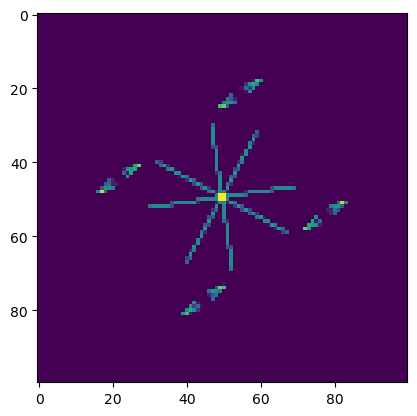

In [6]:
plt.imshow(region_map)

In [62]:
a = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])

a[1:3, 1:3][np.where(a[1:3, 1:3] > 0)] = 99
print(a)
a[a==99] = 100
print(a)

print(np.where(a > 0))

[[ 0  1  2]
 [ 3 99 99]
 [ 6 99 99]]
[[  0   1   2]
 [  3 100 100]
 [  6 100 100]]
(array([0, 0, 1, 1, 1, 2, 2, 2], dtype=int64), array([1, 2, 0, 1, 2, 0, 1, 2], dtype=int64))


## merge test
Conclusion: for region1 = region2 & region3, 
1. if both region2 and region3 have multiple polygons (as long as not single polygon, no matter overlapping or not), the result will necessarily be merged.
2. otherwise (one of them is or both are single polygon) the result is not merged and merged_semantics works.

In [ ]:
layout = kdb.Layout()
layout.read("../test.gds")
top_cell = layout.cell("Top")
layer3 = layout.layer(3, 0)
layer4 = layout.layer(4, 0)
layer5 = layout.layer(5, 0)

region3 = kdb.Region(top_cell.shapes(layer3))
region4 = kdb.Region(top_cell.shapes(layer4))

# region3.merged_semantics = False

region5 = region3 & region4
# region5.merged_semantics = False
# print(region5.area())
# region5.merged_semantics = True
# print(region5.area())

# region5 = region4 & region5
# region5.merge()
for i in region5.each():
	print(1)
# top_cell.shapes(layer5).insert(region5)
# layout.write("../test.gds")


1
1
1


In [108]:
a = np.ones((10, 10))
b = np.zeros((10, 10))

a != b

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]])

In [ ]:
print(Krt.Map.where(-1))
Krt.Map.map[Krt.Map.where(-1)] = 0
print(Krt.Map.where(0))


In [4]:
a = [4,6,2,1,87,2,0]
a.index(1)

3

In [ ]:
for i in range(1):
	print(i)

0


## debug

In [24]:
# Empty region
safely_sized_region = kdb.Region()

region = Krt.obs_region

# Safely size the region
for i in range(20):
    safely_sized_region += region.sized(100*1000 * i / 20)

Krt.cell.shapes(Krt.layout.layer("1000/0")).insert(safely_sized_region)
Krt.save_layout()


Krouter: Layout saved to D:\_Topological quantum computation\PbTe_Pb\S499\S499_contact.GDS.
